# A/B testing for Cookie Cats mobile game
## Introduction
This project utilizes an A/B testing framework to analyze the behavioral impact of shifting a "gate" (a progression barrier) from level 30 to level 40 in a mobile game.

### Core Objectives
The primary goal is to determine how delaying this gate affects two critical metrics:
- Engagement: Measured by the total number of game rounds played (sum_gamerounds).
- Retention: Measured by whether a player returns to the game 1 day (retention_1) and 7 days (retention_7) after installation.

### Data Overview
The analysis is based on user-level data (sourced from Kaggle) that categorizes players into two distinct groups:
- Control Group (gate_30): Players who encountered the gate at level 30.
- Treatment Group (gate_40): Players who encountered the gate at level 40. (moved gate)

### Analysis Strategy
While Day 1 retention captures immediate interest, this study prioritizes Day 7 retention as the primary indicator of long-term engagement and player lifetime value (LTV). Through Exploratory Data Analysis (EDA) and statistical hypothesis testing, we evaluate whether moving the gate further into the game journey enhances the player experience or causes unintended friction that leads to churn.

## Import Libraries

In [50]:
import numpy as np # linear algebra
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from scipy.stats import mannwhitneyu
from IPython.display import display, Markdown

import os

In [2]:
def print_md_title(title):
    display(Markdown(f"**{title}**"))

## Load Dataset

In [3]:
path = '/kaggle/input/mobile-games-ab-testing/cookie_cats.csv'
df = pd.read_csv(path)
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


## Exploratory Data Analysis

In [4]:
print_md_title("Duplicate Rows Check")
dup_count = df.duplicated().sum()
if dup_count == 0:
    print("✅ No duplicate rows found.")
else:
    print(f"⚠️ Found {dup_count} duplicate rows. Dropping them...")
    df.drop_duplicates(keep="first", inplace=True)
    print("✅ Duplicate rows dropped.")

print_md_title("Shape & Columns")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

print_md_title("Dataset Info")
df.info()

print_md_title("Numerical Features Summary")
display(df.describe().T)

print_md_title("Categorical Features Summary")
display(df.describe(include="object").T)

print_md_title("Missing Values")
missing = df.isnull().sum()
total_missing = missing.sum()
total_cells = df.size
missing_percentage = (total_missing / total_cells) * 100

if total_missing == 0:
    print("✅ No missing values found.")
else:
    print(f"⚠️ Missing values detected:")
    print(missing[missing > 0])
    print(f"\nTotal Missing: {total_missing} values ({missing_percentage:.2f}% of the dataset)")

**Duplicate Rows Check**

✅ No duplicate rows found.


**Shape & Columns**

Shape: (90189, 5)
Columns: ['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7']


**Dataset Info**

...

,count,mean,std,min,25%,50%,75%,max
userid,90189.0,4.998412e+06,2.883286e+06,116.0,2512230.0,4995815.0,7496452.0,9999861.0
sum_gamerounds,90189.0,5.187246e+01,1.950509e+02,0.0,5.0,16.0,51.0,49854.0


**Categorical Features Summary**

,count,unique,top,freq
version,90189,2,gate_40,45489


**Missing Values**

✅ No missing values found.


In [5]:
df[df['sum_gamerounds']==49854]

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True


In [6]:
stats = df.groupby('version')['sum_gamerounds'].describe()
print(stats)

           count       mean         std  min  25%   50%   75%      max
version                                                               
gate_30  44700.0  52.456264  256.716423  0.0  5.0  17.0  50.0  49854.0
gate_40  45489.0  51.298776  103.294416  0.0  5.0  16.0  52.0   2640.0


### Plot

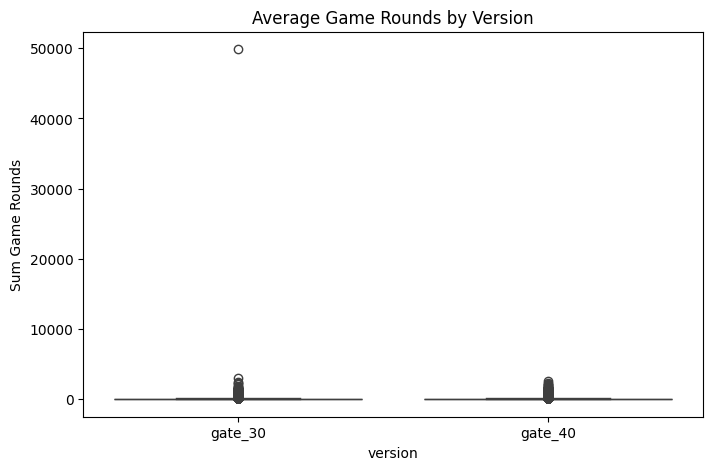

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='version', y='sum_gamerounds', data=df)
plt.title('Average Game Rounds by Version')
plt.ylabel('Sum Game Rounds')
plt.show()

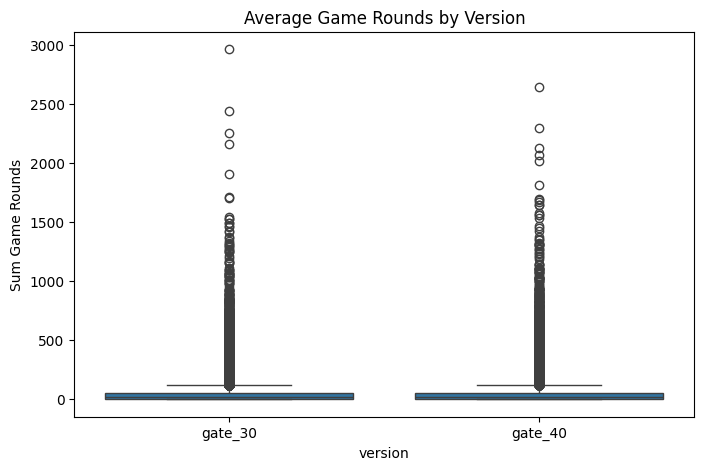

In [8]:
# take away the most obvious outlier (sum_gamerounds == 49854)
df_drop = df[df['sum_gamerounds']<10000]
plt.figure(figsize=(8, 5))
sns.boxplot(x='version', y='sum_gamerounds', data=df_drop)
plt.title('Average Game Rounds by Version')
plt.ylabel('Sum Game Rounds')
plt.show()

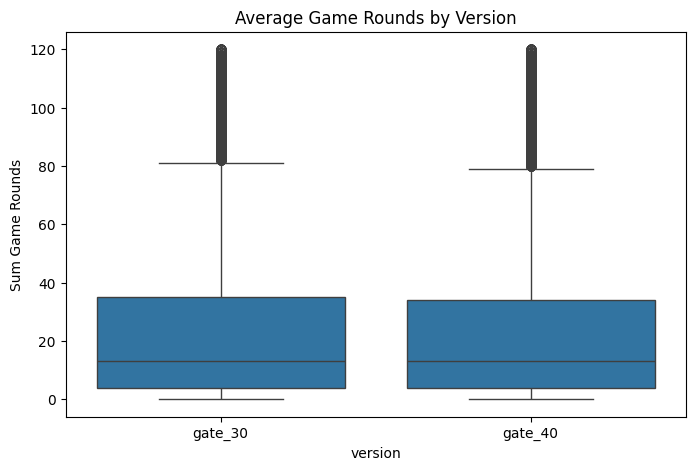

In [9]:
# Compute interquartile range to define bounds, drop extremes
Q1 = df['sum_gamerounds'].quantile(0.25)
Q3 = df['sum_gamerounds'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df_drop_all = df[(df['sum_gamerounds'] >= lower) & (df['sum_gamerounds'] <= upper)]

plt.figure(figsize=(8, 5))
sns.boxplot(x='version', y='sum_gamerounds', data=df_drop_all)
plt.title('Average Game Rounds by Version')
plt.ylabel('Sum Game Rounds')
plt.show()

In [10]:
stats = df_drop_all.groupby('version')['sum_gamerounds'].describe()
print(stats)

           count       mean        std  min  25%   50%   75%    max
version                                                            
gate_30  39638.0  23.945179  27.152547  0.0  4.0  13.0  35.0  120.0
gate_40  40374.0  24.012558  27.800704  0.0  4.0  13.0  34.0  120.0


By dropping most of the outliers with IQR method, the two versions have very similar statistics.

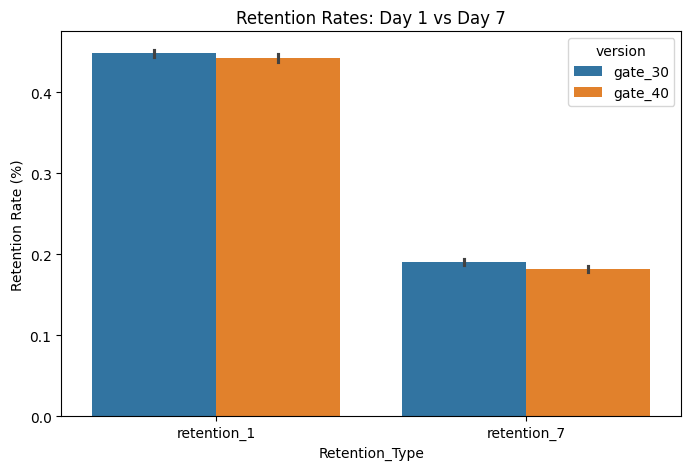

In [11]:
# Reshape data for plotting retention
retention_df = pd.melt(df, id_vars=['version'], value_vars=['retention_1', 'retention_7'], 
                       var_name='Retention_Type', value_name='Retained')

plt.figure(figsize=(8, 5))
sns.barplot(x='Retention_Type', y='Retained', hue='version', data=retention_df)
plt.title('Retention Rates: Day 1 vs Day 7')
plt.ylabel('Retention Rate (%)')
plt.show()

I will drop the extreme outlier found in the first plot since it seems like an invalid datapoint.

In [12]:
df = df[df.sum_gamerounds < 40000]

### Statistical analysis for retention

In [13]:
print(df.groupby('version')[['retention_1', 'retention_7']].agg(['mean', 'std', 'var']))

        retention_1                     retention_7                    
               mean       std       var        mean       std       var
version                                                                
gate_30    0.448198  0.497315  0.247322    0.190183  0.392450  0.154017
gate_40    0.442283  0.496663  0.246674    0.182000  0.385849  0.148879


Even though the difference is tiny, by looking at the mean, we can see that there's slightly better retention after day 1 and day 7 for gate_30. 
The difference on mean for day 1 retention is 0.005915 while there's a bigger difference of 0.008183 for day 7 retention.

In [23]:
gates = ('gate_30', 'gate_40')
days = (1, 7)
rows = []
for gate in gates:
    for day in days:
        col = f"retention_{day}"
        sub_df = df.loc[df["version"] == gate, col]

        nobs = len(sub_df)
        cnt_true = sub_df.sum()
        p_hat = cnt_true / nobs
        ci_low, ci_high = proportion_confint(cnt_true, nobs)

        rows.append({
            "gate": gate,
            "day": day,
            "p_hat": p_hat,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "count": cnt_true,
            "nobs": nobs,
        })

ci_df = pd.DataFrame(rows).sort_values(["day", "gate"]).reset_index(drop=True)
ci_df.round(decimals = 4)

,gate,day,p_hat,ci_low,ci_high,count,nobs
0,gate_30,1,0.4482,0.4436,0.4528,20034,44699
1,gate_40,1,0.4423,0.4377,0.4468,20119,45489
2,gate_30,7,0.1902,0.1865,0.1938,8501,44699
3,gate_40,7,0.1820,0.1785,0.1855,8279,45489


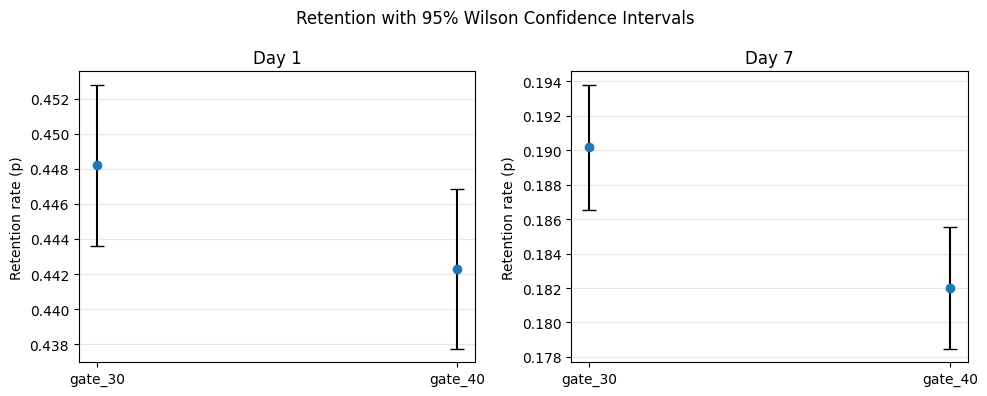

In [24]:
fig, axes = plt.subplots(1, len(days), figsize=(10, 4), sharey=False)

for ax, day in zip(axes, days):
    sub = ci_df[ci_df["day"] == day].reset_index(drop=True)
    x = np.arange(len(sub))

    ax.scatter(x, sub["p_hat"], zorder=3)

    # Error bars
    yerr = np.vstack([
        sub["p_hat"] - sub["ci_low"],
        sub["ci_high"] - sub["p_hat"]
    ])

    ax.errorbar(
        x,
        sub["p_hat"],
        yerr=yerr,
        fmt="none",
        capsize=5,
        color="black",
        zorder=2
    )

    # X-axis labels
    ax.set_xticks(x)
    ax.set_xticklabels(sub["gate"])

    ax.set_title(f"Day {day}")
    ax.set_ylabel("Retention rate (p)")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Retention with 95% Wilson Confidence Intervals")
plt.tight_layout()

For day 1 retention, we can see an overlap of confidence intervals. Does that mean that we'll see no statistical difference in retention on day 1 for the two groups?

Not necessarily. While the confidence intervals for each group overlap, this doesn't rule out a statistically significant difference. Individual CIs are calculated based on each group's specific standard error, but the significance of a test depends on the standard error of the difference between the two groups.

In this case, the data consistently trends toward higher retention for the gate_30 group. The overlap suggests that while the effect size may be small, the results remain compatible with a directional advantage for gate_30 that a formal hypothesis test (like a p-value calculation) may still confirm.

## Hypothesis

Sample size is big, so we will use Z-test.
### For Retention on day 1 (two-sided z-test)
- $p_{30,1}$ = retention rate on day 1 for gate_30 (control group)
- $p_{40,1}$ = retention rate on day 1 for gate_40 (treatment group)
- H0: $p_{30,1} = p_{40,1}$, There's no statistically significant difference in retention rates on day 1 between version gate_30 and gate_40.
- H1: $p_{30,1}$ != $p_{40,1}$, There's a statistically significant difference in retention rates on day 1 between version gate_30 and gate_40.
### For Retention on day 7 (one-sided z-test)
- $p_{30,7}$ = retention rate on day 7 for gate_30 (control group)
- $p_{40,7}$ = retention rate on day 7 for gate_40 (treatment group)
- H0: $p_{30,7} \leq p_{40,7}$, Retention rates on day 7 for gate_30 is not higher than gate_40.
- H1: $p_{30,7}$ > $p_{40,7}$, Retention rates on day 7 for gate_30 is higher than gate_40.

In [26]:
test_df = ci_df[ci_df['day'] == 1]
test_df

,gate,day,p_hat,ci_low,ci_high,count,nobs
0,gate_30,1,0.448198,0.443588,0.452808,20034,44699
1,gate_40,1,0.442283,0.437719,0.446847,20119,45489


In [31]:
count = test_df["count"].to_numpy()
nobs = test_df["nobs"].to_numpy()

z_stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Z-statistic: 1.7871
P-value: 0.0739


The two-sided z test above gives a p-value of 0.0739. At a significance level of $\alpha$=0.05, we do not reject the null hypothesis that H0: $p_{30,1} = p_{40,1}$. This means that the difference in retention rate is not statistically different for the two groups.

In [33]:
test_df = ci_df[ci_df['day'] == 7]
test_df

,gate,day,p_hat,ci_low,ci_high,count,nobs
2,gate_30,7,0.190183,0.186545,0.193821,8501,44699
3,gate_40,7,0.182000,0.178454,0.185546,8279,45489


In [34]:
count = test_df["count"].to_numpy()
nobs = test_df["nobs"].to_numpy()

z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Z-statistic: 3.1574
P-value: 0.0008


The p-value from this z test is 0.0008, which is smaller than a significance level of 0.005. In this case, we will reject null hypothesis. There's statistically significant difference and gate_30 has higher day-7 retention rate than gate_40.

### For Game Rounds (engagement):
- H0: There's no statistically significant difference in sum of game rounds between version gate_30 and gate_40.
- H1: There's a statistically significant difference in sum of game rounds between version gate_30 and gate_40.

In [40]:
stats_df = df.groupby('version')['sum_gamerounds'].agg(['count', 'mean', 'median', 'std'])
print("Descriptive Statistics:")
print(stats_df)

Descriptive Statistics:
         count       mean  median         std
version                                      
gate_30  44699  51.342111    17.0  102.057598
gate_40  45489  51.298776    16.0  103.294416


In [42]:
group_a = df[df['version'] == 'gate_30']['sum_gamerounds']
group_b = df[df['version'] == 'gate_40']['sum_gamerounds']

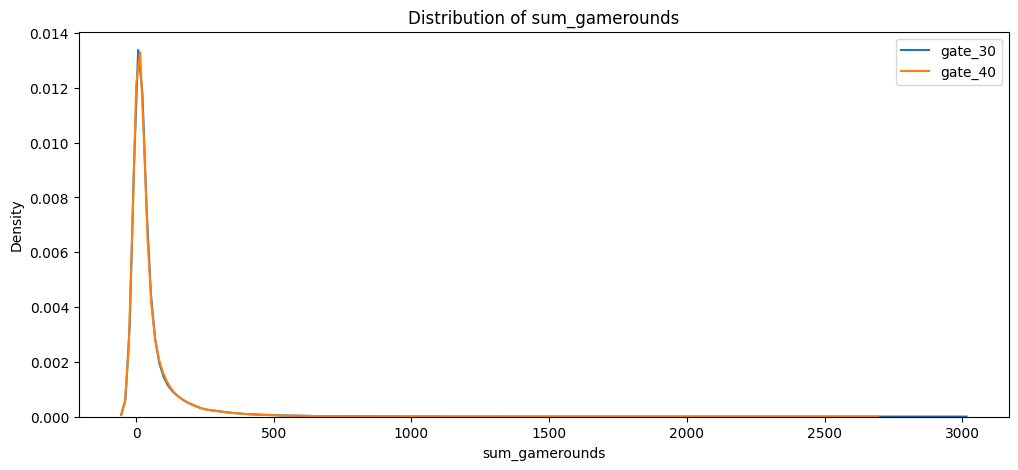

In [45]:
plt.figure(figsize=(12,5))
sns.kdeplot(group_a, label='gate_30', bw_adjust=1.5)
sns.kdeplot(group_b, label='gate_40', bw_adjust=1.5)
plt.title('Distribution of sum_gamerounds')
plt.xlabel('sum_gamerounds')
plt.ylabel('Density')
plt.legend()
plt.show()

`sum_gamerounds` is a continuous numeric value that is very skewwed. We will use Mann-Whitney U Test in this case.

In [52]:
stat, p_value = mannwhitneyu(group_a, group_b, alternative='two-sided')
print(f"Mann-Whitney U statistic: {stat}")
print(f"P-value: {p_value}")

Mann-Whitney U statistic: 1024285761.5
P-value: 0.05089155279145376


The U test gives a p-value of 0.0509, which is bigger than a significance level of $\alpha$=0.05. Therefore, we fail to reject null hypothesis. There's no enough evidence to say there is a significant difference in engagement between gate_30 and gate_40.

#### Why is the P-value so close?

When you have a massive sample and the p-value is still hovering around 0.05, it usually means:
- Small Effect Size: The actual difference in rounds played between the two groups is likely very small.
- High Variance: Even with many users, the "sum of game rounds" likely varies wildly (some people play 1 round, some play 1,000), which creates "noise" that drowns out the signal.

In [53]:
df.groupby('version')['sum_gamerounds'].median()

version
gate_30    17.0
gate_40    16.0
Name: sum_gamerounds, dtype: float64

## Conclusion
|Metric|Test Used|P-Value|Result|Conclusion|
|------|---------|-------|------|----------|
|Day 1 Retention|Two-sided Z-test|0.0739|Not Significant|No immediate impact on short-term return rates.|
|Day 7 Retention|Two-sided Z-test|0.0008|Significant|Gate 30 performs significantly better than Gate 40.|
|Game Engagement|Mann-Whitney U|0.0509|Not Significant|No statistical difference in total rounds played.|


Analysis of Findings
- Engagement vs. Retention: Interestingly, players aren't necessarily playing fewer rounds in total (sum_gamerounds), but they are significantly less likely to remain active after one week when the gate is moved to level 40. This suggests that the placement of the gate at level 30 provides a better "hook" or pacing for long-term player commitment.
- The Day 1 "Trend": While Day 1 retention did not meet the $\alpha=0.05$ threshold, its p-value (0.0739) shows a slight trend that aligns with the Day 7 findings.
- Statistical vs. Practical Significance: The Day 7 retention result is highly robust ($p < 0.001$). Even if engagement metrics seem "flat" ($p = 0.0509$), the drop in long-term retention represents a clear risk to the game's player base over time.

The data suggests that moving the gate from Level 30 to Level 40 has a negative impact on long-term player retention.

While the change does not significantly alter the number of rounds played in the short term, the Day 7 retention rate—a critical KPI for game longevity—decreased significantly in the gate_40 group. Because the primary goal of gate placement is to optimize the balance between challenge and progress to keep players coming back, the original placement at Level 30 is the superior version for maintaining a healthy, active user base.